In [20]:
import os 
import json
import logging
logger = logging.getLogger(__name__)
from gen3.auth import Gen3Auth
from gen3.query import Gen3Query
from tools import (
    _download_file_sync,
    _convert_dicom_to_jpeg,
)


case_id = "419639-011274"
result = {"age": None, "sex": None, "x_ray_jpeg": [], "x_ray_dicom": []}
MIDRC_API = "https://data.midrc.org"

# Create temporary directory for downloads and conversions
# temp_dir = tempfile.mkdtemp(prefix="midrc_download_")
case_dir = f"database/midrc_files/{case_id}"
os.makedirs(case_dir, exist_ok=True)

result_cache = os.path.join(case_dir, "result_cache.json")
if os.path.exists(result_cache):
    logger.info(f"Loading cached results for case {case_id}")
    with open(result_cache, "r") as f:
        result = json.load(f)
else:
    # Initialize Gen3 authentication and query client
    auth = Gen3Auth(MIDRC_API, refresh_file=os.environ.get("MIDRC_CREDENTIALS_PATH"))
    query = Gen3Query(auth)

    # Step 1: Get case information to extract patient demographics
    logger.info(f"Querying case information for case_id: {case_id}")
    case_info = query.raw_data_download(
        data_type="case",
        fields=None,
        filter_object={"AND": [{"IN": {"submitter_id": [case_id]}}]},
        sort_fields=[{"submitter_id": "asc"}],
    )
    # Extract patient demographics from case info
    if case_info and len(case_info) > 0:
        case_data = case_info[0]
        result["age"] = case_data.get("age_at_index")
        result["sex"] = case_data.get("sex")
        result["measurements"] = case_data.get("measurements", [])
        result["medications"] = case_data.get("medications", [])
        logger.info(f"Found patient demographics - Age: {result['age']}, Sex: {result['sex']}")
    if len(case_info) > 0 and "submitter_id" in case_info[0]:
        case_ids = [i["submitter_id"] for i in case_info]

In [21]:
# Step 2: Get X-ray files associated with the case
logger.info(f"Querying X-ray files for case_id: {case_id}")
x_ray_files = query.raw_data_download(
    data_type="data_file",
    fields=None,
    filter_object={"IN": {"case_ids": [case_id]}},
    sort_fields=[{"submitter_id": "asc"}],
)

In [22]:
import os
import shutil

def flat_files(base_path="."):
    base_path = os.path.abspath(base_path)

    for root, dirs, files in os.walk(base_path, topdown=False):
        if root == base_path:
            continue  # Skip the base directory

        for file in files:
            src = os.path.join(root, file)
            dst = os.path.join(base_path, file)
            # If a file with the same name exists, skip it 
            if os.path.exists(dst):
                continue
            else:
                shutil.move(src, dst)

        # Remove empty directory
        for d in dirs:
            shutil.rmtree(os.path.join(root, d), ignore_errors=True)
        shutil.rmtree(root, ignore_errors=True)


In [23]:
import zipfile 
def _extract_archive(archive_path: str, output_dir: str):
    """
    Extract ZIP/TAR archives and return list of extracted files.
    """
    extracted_files = []
    try:
        if archive_path.lower().endswith(".zip"):
            with zipfile.ZipFile(archive_path, "r") as zip_ref:
                zip_ref.extractall(output_dir)

            # Find all extracted files
            for root, dirs, files in os.walk(output_dir):
                for file in files:
                    if file != os.path.basename(archive_path):  # Skip the original archive
                        file_path = os.path.join(root, file)
                        extracted_files.append(file_path)

        os.remove(archive_path)

        logger.info(f"Extracted {len(extracted_files)} files from {archive_path}")
    except Exception as e:
        logger.error(f"Error extracting archive {archive_path}: {e}")

    return extracted_files


In [ ]:
# Step 3: Download and process X-ray files (DICOM and JPEG)
if x_ray_files:
    logger.info(f"Found {len(x_ray_files)} X-ray files")
    cred_path = os.environ.get("MIDRC_CREDENTIALS_PATH")
    dicoms = []
    jpegs = []
    for file_info in x_ray_files:
        if "object_id" in file_info:
            object_id = file_info["object_id"]
            print(f"Downloading file with object_id: {object_id}")
            case_path = os.path.abspath(case_dir)
            download_result = _download_file_sync(object_id, cred_path, case_path)

    flat_files(case_dir)
    for f in os.listdir(case_dir):
        if f.lower().endswith((".zip", ".tar", ".gz")):
            extracted_files = _extract_archive(os.path.join(case_dir, f), case_dir)
    flat_files(case_dir)

    for f in os.listdir(case_dir):
        if f.lower().endswith((".dcm", ".dicom")):
            dicoms.append(os.path.join(case_dir, f))
            jpeg_path = _convert_dicom_to_jpeg(os.path.join(case_dir, f), case_dir)
            if jpeg_path:
                jpegs.append(jpeg_path)
                logger.info(f"Converted DICOM to JPEG: {jpeg_path}")

logger.info(
    f"Successfully processed case {case_id}. Found {len(result['x_ray_jpeg'])} JPEG and {len(result['x_ray_dicom'])} DICOM X-ray images."
)
# print(result)

# UDI Grammar Workflow Demo

This notebook demonstrates a complete workflow for visualizing DICOM metadata using the UDI grammar system.

**Workflow steps:**
1. Extract DICOM metadata from a directory of .dcm files and save selected attributes to a CSV file.
2. Load the CSV in Python and generate a UDI grammar specification for a bar chart (with faceting by Modality).
3. Render the UDI grammar spec to a PNG image and display it in the notebook.

---

## Step 1: Extract DICOM Metadata to CSV
 We use the `extract_usecase_columns` function from our DICOM metadata utility.
This function scans a directory for DICOM (.dcm) files, extracts a set of interesting metadata fields (such as PatientAge, Modality, Manufacturer, etc.), and writes them to a CSV file.

This CSV will be used as the data source for visualization in later steps.

In [ ]:
from read_dicom_metadata import extract_usecase_columns
import os 
# Please use the patient ID 419639-011274
dicom_dir = [f'../umls_data/{f}' for f in os.listdir('../umls_data/')]
csv_path = 'usecase_col1_011274.csv'
extract_usecase_columns(dicom_dir, csv_path)
print(f'CSV written to {csv_path}')

Error reading ../umls_data/usecase.py: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
Wrote selected metadata for 1 DICOM files to usecase_col1_011274.csv
CSV written to usecase_col1_011274.csv


## Step 1.1 upload the CSV to S3 for later use

In [ ]:
import os

local_csv = csv_path
bucket = "neural-science"

# Construct the AWS CLI command
cmd = f"aws s3 cp {local_csv} s3://{bucket}/{csv_path}"

# Run the command and print output
result = os.system(cmd)
if result == 0:
    print(f"Successfully uploaded {local_csv} to s3://{bucket}/{csv_path}")
else:
    print("Upload failed. Make sure AWS CLI is installed and configured.")

upload: ./usecase_col1_011274.csv to s3://neural-science/usecase_col1_011274.csv
Successfully uploaded usecase_col1_011274.csv to s3://neural-science/usecase_col1_011274.csv


## Step 2: Generate a UDI Grammar Specification

We now load the CSV and use the `udi-grammar-py` library to build a UDI grammar specification for a bar chart.

- **X-axis:** PatientAge (nominal)
- **Y-axis:** Count of records
- **Color:** PatientSex
- **Facet (column):** Modality

We patch the rollup part of the spec to ensure it is valid for the UDI grammar web app, and add the column encoding manually for faceting.

The resulting spec can be used in the UDI web editor or for automated rendering.

In [ ]:
from udi_grammar_py.spec import Chart
from udi_grammar_py.helpers import Op
import json

def make_udi_spec(csv_path):
    chart = (
        Chart()
        .source('dicom', csv_path)
        .groupby(['PatientAge', 'Modality', 'PatientSex'])
        .rollup('count', count=Op.count())
        .mark('bar')
        .x(field='PatientAge', type='nominal')
        .y(field='count', type='quantitative')
        .color(field='PatientSex', type='nominal')
    )
    spec = chart.to_dict()
    for t in spec['transformation']:
        if 'rollup' in t and isinstance(t['rollup'], str):
            t['rollup'] = {'count': {'op': 'count'}}
    # Add column encoding manually for faceting by Modality
    spec['representation']['mapping'].append({
        'encoding': 'column',
        'field': 'Modality',
        'type': 'nominal'
    })
    return spec

def make_udi_spec_visitdate(csv_path):
    from udi_grammar_py.spec import Chart
    from udi_grammar_py.helpers import Op

    chart = (
        Chart()
        .source('dicom', csv_path)
        .groupby(['StudyDate'])
        .rollup('count', count=Op.count())
        .mark('bar')
        .x(field='StudyDate', type='nominal')
        .y(field='count', type='quantitative')
    )
    spec = chart.to_dict()
    for t in spec['transformation']:
        if 'rollup' in t and isinstance(t['rollup'], str):
            t['rollup'] = {'count': {'op': 'count'}}
    return spec


csv_path_s3 = f"https://{bucket}.s3.us-east-1.amazonaws.com/{csv_path}"
udi_spec = make_udi_spec_visitdate(csv_path_s3)
print(json.dumps(udi_spec, indent=2))

{
  "source": {
    "name": "dicom",
    "source": "https://neural-science.s3.us-east-1.amazonaws.com/usecase_col1_011274.csv"
  },
  "transformation": [
    {
      "groupby": [
        "StudyDate"
      ]
    },
    {
      "rollup": {
        "count": {
          "op": "count"
        }
      }
    }
  ],
  "representation": {
    "mark": "bar",
    "mapping": [
      {
        "encoding": "x",
        "field": "StudyDate",
        "type": "nominal"
      },
      {
        "encoding": "y",
        "field": "count",
        "type": "quantitative"
      }
    ]
  }
}


## Step 3: Render the UDI Spec to an Image

We use the `udi_to_png` function to render the UDI grammar spec to a PNG image.
This function launches a headless browser, loads the UDI web editor with the spec, and downloads the resulting chart as a PNG.

We then display the image directly in the notebook.

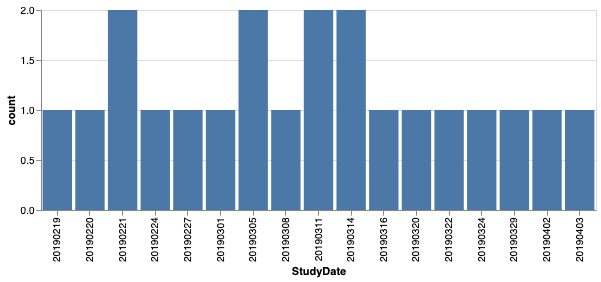

In [ ]:
import asyncio
from udi_grammar_wrapper import udi_to_png
from IPython.display import Image, display

output_img = 'udi_chart_studydate.png'
# Render the image (Jupyter supports top-level await)
await udi_to_png(udi_spec, output_img)
display(Image(output_img))

---

## An Interactive Option: UDI Web Interface in Notebook

You can interactively explore and edit UDI grammar specifications using the official UDI web editor, embedded below.

**How to use:**
- Copy the generated UDI spec from Python (see above) and paste it into the editor's text box.
- The visualization will update automatically.
- You can also edit the spec directly in the web interface.

---

In [ ]:
from IPython.display import HTML
HTML("<iframe src='https://hms-dbmi.github.io/udi-grammar/#/Editor' width='1200' height='1000'></iframe>")